STEP 1: PROBLEM DEFINITION
----------------------------------------
PROBLEM: Predict whether a loan applicant will DEFAULT (1) or NOT DEFAULT (0)

GOAL: Binary classification

SUCCESS CRITERIA:
- Accuracy: >80%
- Precision: >75%
- Recall: >70%
- F1-Score: >72%

# STEP 2: DATA COLLECTION
 - Source: Kaggle dataset 'loan_default_prediction.csv'
 - This dataset contains loan application information with a binary target indicating default (1) or not (0).
 - It includes features relevant to credit risk assessment (income, loan amount, employment status, etc.).

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('loan_default_prediction.csv')

# Quick check that data represents the problem domain
print("Step 2: Data Collection")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Default rate: {df['default'].mean()*100:.2f}%")

Step 2: Data Collection
Dataset shape: 1000 rows, 5 columns
Default rate: 48.70%


# STEP 3: DATA EXPLORATION AND PREPARATION
 # 3.1 Exploratory Data Analysis (EDA): 
 - Understand distributions of target and key features
- Visualize relationships between features and default status
- Identify trends (e.g., income/loan amount differences by default)

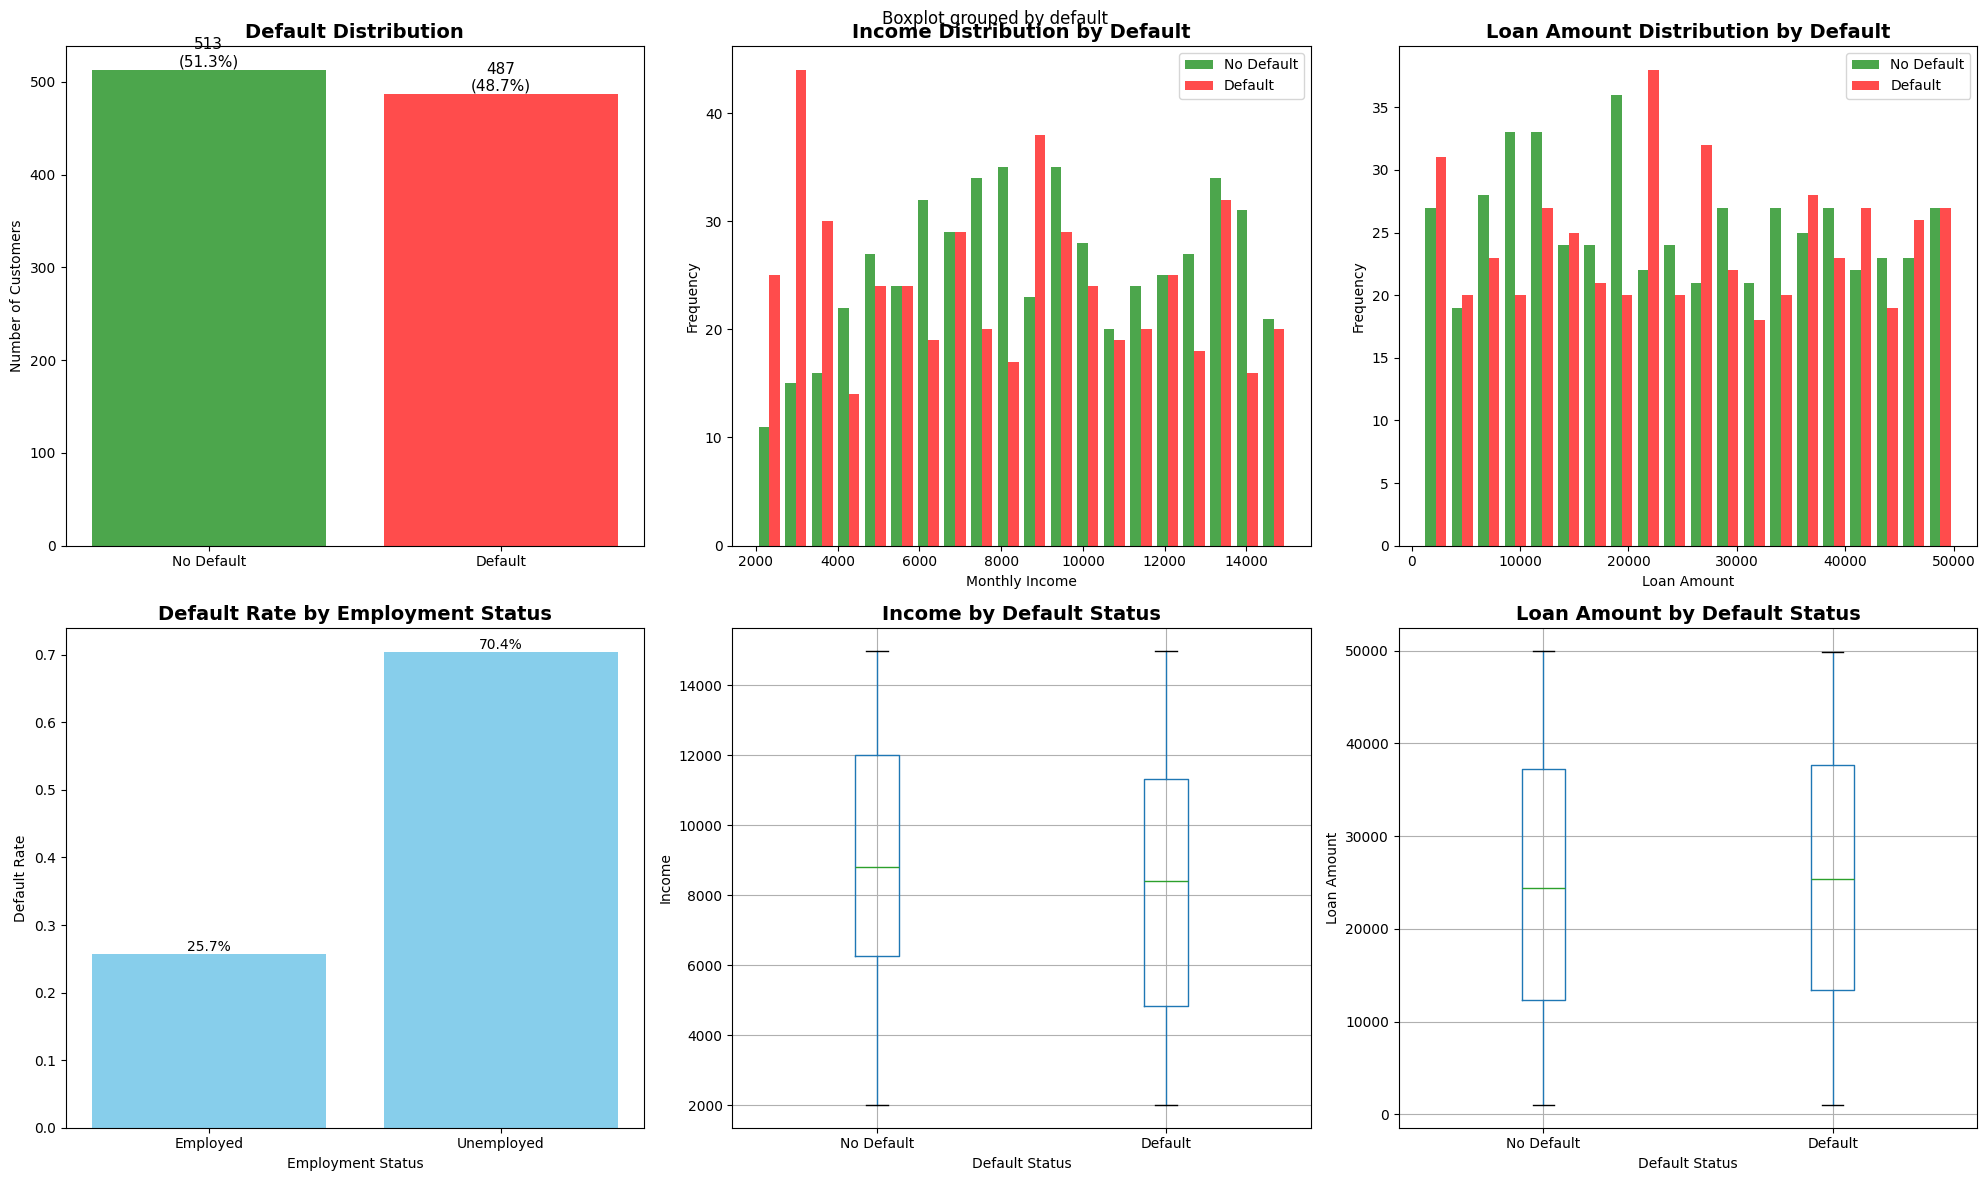

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Create a figure with multiple subplots to explore data
fig = plt.figure(figsize=(20, 12))
fig.suptitle("EDA: Loan Default Prediction", fontsize=16, y=0.98)

# 1. Target variable distribution
ax1 = plt.subplot(2, 3, 1)
default_counts = df['default'].value_counts()
colors = ['green', 'red']
bars = ax1.bar(['No Default', 'Default'], default_counts.values, color=colors, alpha=0.7)
ax1.set_title('Default Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Customers')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11)

# 2. Income distribution by default status
ax2 = plt.subplot(2, 3, 2)
ax2.hist([df[df['default']==0]['income'], df[df['default']==1]['income']],
         bins=20, label=['No Default', 'Default'], alpha=0.7, color=['green', 'red'])
ax2.set_title('Income Distribution by Default', fontsize=14, fontweight='bold')
ax2.set_xlabel('Monthly Income')
ax2.set_ylabel('Frequency')
ax2.legend()

# 3. Loan amount distribution by default status
ax3 = plt.subplot(2, 3, 3)
ax3.hist([df[df['default']==0]['loan_amount'], df[df['default']==1]['loan_amount']],
         bins=20, label=['No Default', 'Default'], alpha=0.7, color=['green', 'red'])
ax3.set_title('Loan Amount Distribution by Default', fontsize=14, fontweight='bold')
ax3.set_xlabel('Loan Amount')
ax3.set_ylabel('Frequency')
ax3.legend()

# 4. Default rate by employment status
ax4 = plt.subplot(2, 3, 4)
emp_default = df.groupby('employment_status')['default'].mean().sort_values()
bars = ax4.bar(emp_default.index, emp_default.values, color='skyblue')
ax4.set_title('Default Rate by Employment Status', fontsize=14, fontweight='bold')
ax4.set_ylabel('Default Rate')
ax4.set_xlabel('Employment Status')
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{height*100:.1f}%', ha='center', va='bottom', fontsize=10)

# 5. Box plot: income vs default
ax5 = plt.subplot(2, 3, 5)
df.boxplot(column='income', by='default', ax=ax5)
ax5.set_title('Income by Default Status', fontsize=14, fontweight='bold')
ax5.set_xlabel('Default Status')
ax5.set_ylabel('Income')
ax5.set_xticklabels(['No Default', 'Default'])

# 6. Box plot: loan amount vs default
ax6 = plt.subplot(2, 3, 6)
df.boxplot(column='loan_amount', by='default', ax=ax6)
ax6.set_title('Loan Amount by Default Status', fontsize=14, fontweight='bold')
ax6.set_xlabel('Default Status')
ax6.set_ylabel('Loan Amount')
ax6.set_xticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()


# 3.2: DATA CLEANING
- Handle missing values, remove duplicates, and cap outliers
- to prepare data for modeling.

In [3]:

df_clean = df.copy()

# 1. Missing values
missing = df_clean.isnull().sum()
if missing.sum() > 0:
    # For simplicity, drop rows with missing values (or impute if needed)
    df_clean = df_clean.dropna()
    print(f"Dropped rows with missing values. New shape: {df_clean.shape}")

# 2. Duplicates
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows.")

# 3. Outliers (capping using IQR)
numerical_cols = ['income', 'loan_amount']
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower, upper)

print(f"\nCleaning complete. Final shape: {df_clean.shape}")


Cleaning complete. Final shape: (1000, 5)


#  3.3: FEATURE ENGINEERING
- Create new features, encode categorical variables, and scale numerical features.

In [4]:
# STEP 3.3: FEATURE ENGINEERING
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler

df_fe = df_clean.copy()

# Create new features
df_fe['income_to_loan'] = df_fe['income'] / df_fe['loan_amount']
df_fe['loan_to_income'] = df_fe['loan_amount'] / df_fe['income']

# One-hot encode employment_status
df_fe = pd.get_dummies(df_fe, columns=['employment_status'], prefix='emp', drop_first=True)

# Scale numerical features
numerical_cols = ['income', 'loan_amount', 'income_to_loan', 'loan_to_income']
scaler = StandardScaler()
df_fe[numerical_cols] = scaler.fit_transform(df_fe[numerical_cols])

print(f"Feature engineering complete. New shape: {df_fe.shape}")

Feature engineering complete. New shape: (1000, 7)


In [5]:
import joblib

# Save the fitted scaler
joblib.dump(scaler, 'scaler.pkl')

# Save the feature column names (the order matters for prediction)
feature_columns = df_fe.drop(['default', 'loan_id'], axis=1).columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')

['feature_columns.pkl']

#  3.4: DATA SPLITTING
- Split the fully engineered data into training, validation, and test sets

In [6]:
# STEP 3.4: DATA SPLITTING
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split

X = df_fe.drop(['default', 'loan_id'], axis=1)
y = df_fe['default']

# Split into train (60%), val (20%), test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

Training set: 600 samples
Validation set: 200 samples
Test set: 200 samples


# STEP 4 & 5: ALGORITHM SELECTION, MODEL DEVELOPMENT, AND TRAINING

## 4. Algorithm Selection
- Algorithm: Linear Regression (supervised, regression)
-  Rationale: Low complexity, high interpretability, suitable for predicting continuous target.
-   Default hyperparameters are used (fit_intercept=True, copy_X=True).

## 5. Model Development and Training

- Design and create the model

In [7]:

from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Train the model on the training dataset
model.fit(X_train, y_train)

# Evaluate on validation set (optional, but helps verify training)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

y_pred = model.predict(X_val)
rmse = math.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print("Linear Regression trained.")
print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

Linear Regression trained.
RMSE: 0.4677 | MAE: 0.4146 | R²: 0.1243


# STEP 6: MODEL EVALUATION AND HYPERPARAMETER TUNING

In [8]:

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# 1. Baseline Linear Regression (no regularization)
print("BASELINE: Linear Regression")
baseline = LinearRegression()
baseline.fit(X_train, y_train)

y_pred_train_base = baseline.predict(X_train)
y_pred_val_base = baseline.predict(X_val)

rmse_train_base = np.sqrt(mean_squared_error(y_train, y_pred_train_base))
rmse_val_base = np.sqrt(mean_squared_error(y_val, y_pred_val_base))
r2_train_base = r2_score(y_train, y_pred_train_base)
r2_val_base = r2_score(y_val, y_pred_val_base)

print(f"Train RMSE: {rmse_train_base:.4f} | Val RMSE: {rmse_val_base:.4f}")
print(f"Train R²: {r2_train_base:.4f} | Val R²: {r2_val_base:.4f}")

# Identify underfitting/overfitting
if r2_train_base - r2_val_base > 0.1:
    print("→ Overfitting detected (train R² much higher than validation R²)")
elif r2_train_base < 0.5 and r2_val_base < 0.5:
    print("→ Possible underfitting (low R² scores)")
else:
    print("→ No severe overfitting/underfitting detected.")

# 2. Hyperparameter tuning for Ridge and Lasso
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

print("\nTuning Ridge...")
ridge = Ridge()
ridge_grid = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_

print("Tuning Lasso...")
lasso = Lasso(max_iter=10000)
lasso_grid = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train, y_train)
best_lasso = lasso_grid.best_estimator_

# 3. Evaluate best models
models = {'Ridge': best_ridge, 'Lasso': best_lasso}
print("\nOPTIMIZED MODELS")
print("-" * 40)

for name, model in models.items():
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    r2_train = r2_score(y_train, y_pred_train)
    r2_val = r2_score(y_val, y_pred_val)
    
    print(f"{name} (alpha={model.alpha if hasattr(model,'alpha') else 'N/A'}):")
    print(f"  Train RMSE: {rmse_train:.4f} | Val RMSE: {rmse_val:.4f}")
    print(f"  Train R²: {r2_train:.4f} | Val R²: {r2_val:.4f}")

# 4. Choose best model based on validation RMSE
best_model_name = min(models, key=lambda x: np.sqrt(mean_squared_error(y_val, models[x].predict(X_val))))
best_model = models[best_model_name]
print(f"\nBest model: {best_model_name}")

BASELINE: Linear Regression
Train RMSE: 0.4401 | Val RMSE: 0.4677
Train R²: 0.2249 | Val R²: 0.1243
→ Overfitting detected (train R² much higher than validation R²)

Tuning Ridge...
Tuning Lasso...

OPTIMIZED MODELS
----------------------------------------
Ridge (alpha=1):
  Train RMSE: 0.4401 | Val RMSE: 0.4675
  Train R²: 0.2249 | Val R²: 0.1248
Lasso (alpha=0.01):
  Train RMSE: 0.4413 | Val RMSE: 0.4697
  Train R²: 0.2207 | Val R²: 0.1166

Best model: Ridge


In [9]:
joblib.dump(best_model, 'loan_default_model.pkl')

['loan_default_model.pkl']

# STEP 8: MODEL TESTING AND DEPLOYMENT

In [10]:
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Assume best_model is your final tuned model
# X_test, y_test are your test set
# scaler is the StandardScaler fitted on training data
# feature_columns is the list of column names in the exact order used in training

# 1. Evaluate on test set
y_pred_test = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("Final Model Performance on Test Set")
print("-" * 35)
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE:  {mae_test:.4f}")
print(f"R²:   {r2_test:.4f}")

# 2. Save all objects needed for deployment
joblib.dump(best_model, 'loan_default_model.pkl')
joblib.dump(scaler, 'scaler.pkl')                      # <-- needed for scaling
joblib.dump(feature_columns, 'feature_columns.pkl')    # <-- needed for feature order

print("\nModel, scaler, and feature columns saved.")

Final Model Performance on Test Set
-----------------------------------
RMSE: 0.4139
MAE:  0.3622
R²:   0.3143

Model, scaler, and feature columns saved.
